# Testing reports

## Imports

In [1]:
from tqdm import tqdm
import polars as pl
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
from pathlib import Path
import torch
import torchaudio
import jiwer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from wav2vec2decoder import Wav2Vec2Decoder

## Precalculations
Так как работаем мы только с декодингом, есть смысл один раз посчитать все выводы модели для датасетов и сохранить их в csv, а потом просто читать их и декодировать.
Для этого обработаем датасеты акустической моделью и модифицируем декодер, чтобы он на вход ждал не audio, а готовый tensor

In [2]:
model_name="facebook/wav2vec2-base-100h"

In [3]:
processor = Wav2Vec2Processor.from_pretrained(model_name)
model = Wav2Vec2ForCTC.from_pretrained(model_name)

/Users/petr.marfutenko/Desktop/ai-talent-hub-itmo-speech-course/assignments/assignment2/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at facebook/wav2vec2-base-100h were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v', 'wav2vec2.mask_time_emb_vector']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a Bert

In [4]:
def get_model_ouputs(audio_path: str):
    audio_input, sr = torchaudio.load(audio_path)
    assert sr == 16000, f"Expected 16 kHz, got {sr} Hz for {audio_path}"
    inputs = processor(audio_input, return_tensors="pt", sampling_rate=16000)
    with torch.no_grad():
        logits = model(inputs.input_values.squeeze(0)).logits[0]

    return logits

In [5]:
datasets = ['earnings22_test', 'librispeech_test_other']

ext_ds = {}

for dataset in datasets:
    ds_path = Path('data') / dataset
    manifest_path = ds_path / 'manifest.csv'

    df = pl.read_csv(manifest_path)
    
    logits_list = []

    for path in tqdm(df["path"]):
        logits_list.append(get_model_ouputs(path))

    df = df.with_columns(
        pl.Series("logits", logits_list)
    )

    ext_ds[dataset] = df

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [01:44<00:00,  1.92it/s]


In [6]:
def evaluate_ds(ds_name: str, predictor):
    if ds_name not in datasets:
        raise ValueError('Possible datasets is earnings22_test, librispeech_test_other')
    hyps = []
    df = ext_ds[ds_name]
    for row in tqdm(df.iter_rows(named=True), total=df.height):
        hyp = predictor(tensor=row['logits'])
        hyps.append(hyp)

    ground_truth = ext_ds[ds_name].get_column("text").to_list()
    wer = jiwer.wer(ground_truth, hyps)
    cer = jiwer.cer(ground_truth, hyps)

    return wer, cer


### Итого:
- Моджифицировали декодер, теперь он ждет в себя torch.Tensor [T, V], который надо просто декодировать
- Прогнали оба датасета акустической моделькой и запомнили выводы
- Написана функция для валидация какого-то `predictor` на всем датасете

## Task 1 `greedy decode`
Проверим работу greedy декодера

In [7]:
decoder = Wav2Vec2Decoder(lm_model_path=None)  # set lm_model_path for Tasks 4+

def predictor(tensor: torch.Tensor):
    return decoder.decode(method='greedy', raw_logits=tensor)

wer, cer = evaluate_ds(ds_name='librispeech_test_other', predictor=predictor)

Some weights of the model checkpoint at facebook/wav2vec2-base-100h were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v', 'wav2vec2.mask_time_emb_vector']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-100h and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'wav

In [8]:
print('Metrics on librispeech_test_other:')
print(f'\tWER: {wer}')
print(f'\tCER: {cer}')

Metrics on librispeech_test_other:
	WER: 0.11219750672207285
	CER: 0.038127997674531275


### Выводы
*greedy_decode* реализован, метрики +- такие же как те, на которые стоит ориентироваться:  
- WER = 0.11219750672207285
- CER = 0.038127997674531275

## Task 2 `beam search decode`
Проверим работу CTC beam search c разными beam_width

In [1]:
def run_experiment(beam_width: int, method: str = "beam"):
    decoder = Wav2Vec2Decoder(
        lm_model_path=None,
        beam_width=beam_width
    )

    def predictor(tensor: torch.Tensor):
        return decoder.decode(raw_logits=tensor, method=method)

    wer, cer = evaluate_ds(
        ds_name='librispeech_test_other',
        predictor=predictor
    )

    return {
        "beam_width": beam_width,
        "wer": wer,
        "cer": cer
    }

In [11]:
beam_widths = [1, 3, 10, 50]

results = []

for bw in beam_widths:
    print(f"Running beam_width={bw}...")
    res = run_experiment(beam_width=bw, method="beam")
    results.append(res)

print(results)

Running beam_width=1...


Some weights of the model checkpoint at facebook/wav2vec2-base-100h were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v', 'wav2vec2.mask_time_emb_vector']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-100h and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'wav

Running beam_width=3...


Some weights of the model checkpoint at facebook/wav2vec2-base-100h were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v', 'wav2vec2.mask_time_emb_vector']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-100h and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'wav

Running beam_width=10...


Some weights of the model checkpoint at facebook/wav2vec2-base-100h were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v', 'wav2vec2.mask_time_emb_vector']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-100h and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'wav

Running beam_width=50...


Some weights of the model checkpoint at facebook/wav2vec2-base-100h were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v', 'wav2vec2.mask_time_emb_vector']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-100h and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'wav

[{'beam_width': 1, 'wer': 0.4458567587386947, 'cer': 0.1437914829707863}, {'beam_width': 3, 'wer': 0.3040821315081887, 'cer': 0.09553800687951165}, {'beam_width': 10, 'wer': 0.2671718406257639, 'cer': 0.08318395426578169}, {'beam_width': 50, 'wer': 0.2505499877780494, 'cer': 0.0780000968945303}]


   beam_width       wer       cer
0           1  0.445857  0.143791
1           3  0.304082  0.095538
2          10  0.267172  0.083184
3          50  0.250550  0.078000


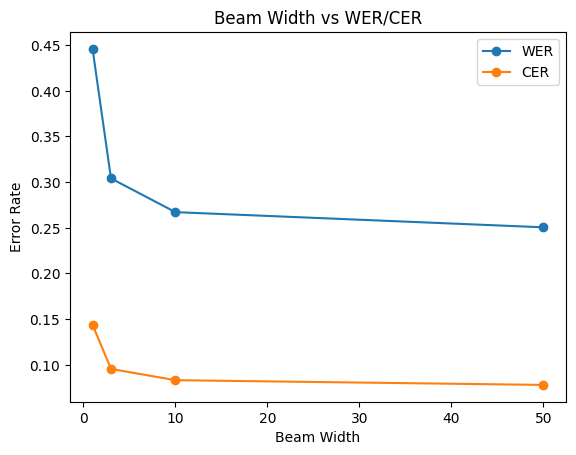

In [12]:
df = pd.DataFrame(results)
print(df)

plt.figure()
plt.plot(df["beam_width"], df["wer"], marker='o')
plt.plot(df["beam_width"], df["cer"], marker='o')

plt.xlabel("Beam Width")
plt.ylabel("Error Rate")
plt.title("Beam Width vs WER/CER")
plt.legend(["WER", "CER"])

plt.show()

### Выводы
Увеличение `beam_width` с 3 до 10 увеличивает временные затраты больше чем в 5 раз, при незначительном приросте качества. Притом, что при увеличении `beam_width` с 1 до 3 увеличивает временные затраты в 14 раз, но ждать 14 минут более приемлемо, чем 1:20 (час двадцать) плюс прирост качества более значимый. Наиболее релеватно будет использования `beam_width` равным 3 (но иногда будет вылезать 10, там где можно было потратить чуть больше времени)

## Task 3 Temperature scaling for `greedy` decoding
Проверим влияние температуры на `greedy` decoding

In [13]:
temperatures = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]

results = []

decoder = Wav2Vec2Decoder(
    lm_model_path=None
)

for T in temperatures:
    print(f"\nRunning temperature={T}...")
    
    decoder.temperature = T

    def predictor(tensor: torch.Tensor):
        return decoder.decode(raw_logits=tensor, method="greedy")


    wer, cer = evaluate_ds(
        ds_name="librispeech_test_other",
        predictor=predictor
    )


    results.append({
        "temperature": T,
        "wer": wer,
        "cer": cer,
    })

df = pd.DataFrame(results)
print(df)

/Users/petr.marfutenko/Desktop/ai-talent-hub-itmo-speech-course/assignments/assignment2/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at facebook/wav2vec2-base-100h were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v', 'wav2vec2.mask_time_emb_vector']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a Bert


Running temperature=0.5...


100%|██████████| 200/200 [00:00<00:00, 8665.56it/s]



Running temperature=0.8...


100%|██████████| 200/200 [00:00<00:00, 10248.63it/s]


...


Running temperature=1.5...


100%|██████████| 200/200 [00:00<00:00, 10809.64it/s]



Running temperature=2.0...


100%|██████████| 200/200 [00:00<00:00, 10727.26it/s]

   temperature       wer       cer
0          0.5  0.112198  0.038128
1          0.8  0.112198  0.038128
2          1.0  0.112198  0.038128
3          1.2  0.112198  0.038128
4          1.5  0.112198  0.038128
5          2.0  0.112198  0.038128


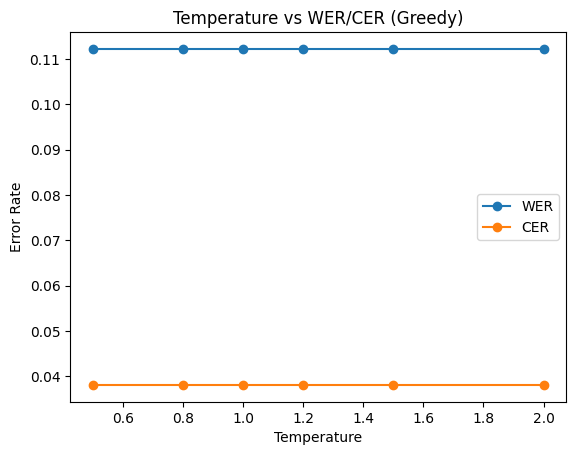

In [14]:
plt.figure()
plt.plot(df["temperature"], df["wer"], marker='o')
plt.plot(df["temperature"], df["cer"], marker='o')

plt.xlabel("Temperature")
plt.ylabel("Error Rate")
plt.title("Temperature vs WER/CER (Greedy)")
plt.legend(["WER", "CER"])

plt.show()

### Выводы
Немного странно получилось, влияние не то, чтобы низкое, его скорее нет. Вообще это логично, ведь мы берем наиболее вероятный токен, а все токены по сути просели пропорционально. По идее температура будет влиять при использовании `beam search`

## Task 4 `beam search with lm`
А тут прикрутим LM модель к beam_search на этап декодинга

In [15]:
alphas = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
betas  = [0.0, 0.5, 1.0, 1.5]

In [2]:
results = []

decoder = Wav2Vec2Decoder(
    lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
    beam_width=10,
    temperature=1.0
)

for alpha in tqdm(alphas, desc="alpha"):
    for beta in betas:
        print(f"alpha={alpha}, beta={beta}")

        decoder.alpha = alpha
        decoder.beta = beta

        def predictor(tensor: torch.Tensor):
            return decoder.decode(raw_logits=tensor, method="beam_lm")

        wer, cer = evaluate_ds(
            ds_name="librispeech_test_other",
            predictor=predictor
        )
        
        results.append({
            "alpha": alpha,
            "beta": beta,
            "wer": wer,
            "cer": cer
        })

df = pd.DataFrame(results)
print(df)

/Users/petr.marfutenko/Desktop/ai-talent-hub-itmo-speech-course/assignments/assignment2/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at facebook/wav2vec2-base-100h were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v', 'wav2vec2.mask_time_emb_vector']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a Bert

alpha=0.01, beta=0.0


100%|██████████| 200/200 [01:14<00:00,  2.69it/s]


alpha=0.01, beta=0.5


100%|██████████| 200/200 [01:14<00:00,  2.70it/s]


...

alpha=5.0, beta=1.0


100%|██████████| 200/200 [01:14<00:00,  2.69it/s]


alpha=5.0, beta=1.5


alpha: 100%|██████████| 7/7 [33:57<00:00, 291.00s/it]

    alpha  beta       wer       cer
0    0.01   0.0  0.267172  0.083087
1    0.01   0.5  0.278172  0.086866
2    0.01   1.0  0.301149  0.094763
3    0.01   1.5  0.312393  0.097670
4    0.05   0.0  0.266194  0.082554
5    0.05   0.5  0.276705  0.086236
6    0.05   1.0  0.296993  0.093309
7    0.05   1.5  0.310438  0.096943
8    0.10   0.0  0.265461  0.082360
9    0.10   0.5  0.275483  0.085994
10   0.10   1.0  0.292105  0.091517
11   0.10   1.5  0.308238  0.096168
12   0.50   0.0  0.262039  0.080907
13   0.50   0.5  0.265216  0.082360
14   0.50   1.0  0.272305  0.085073
15   0.50   1.5  0.286238  0.089385
16   1.00   0.0  0.260816  0.079211
17   1.00   0.5  0.261305  0.079793
18   1.00   1.0  0.261061  0.080568
19   1.00   1.5  0.267172  0.083232
20   2.00   0.0  0.417746  0.112785
21   2.00   0.5  0.366414  0.101303
22   2.00   1.0  0.324859  0.091662
23   2.00   1.5  0.311171  0.089482
24   5.00   0.0  0.999756  0.257691
25   5.00   0.5  0.999756  0.257691
26   5.00   1.0  0.999756  0

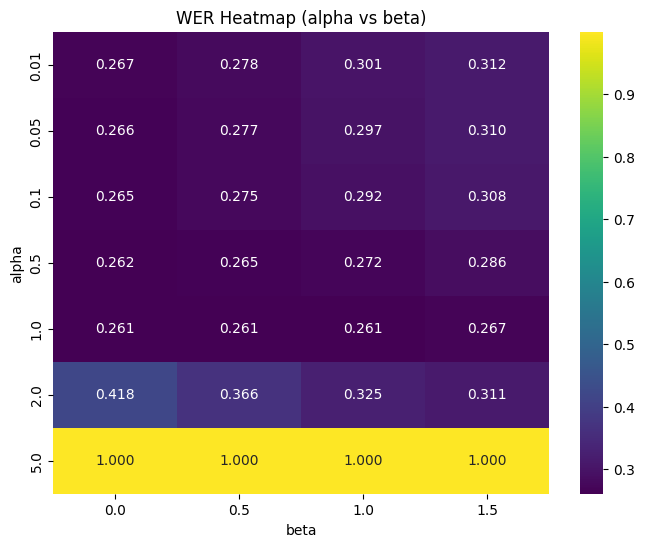

In [17]:
pivot = df.pivot(index="alpha", columns="beta", values="wer")

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")

plt.title("WER Heatmap (alpha vs beta)")
plt.xlabel("beta")
plt.ylabel("alpha")

plt.show()

In [18]:
best = df.loc[df["wer"].idxmin()]
print("BEST CONFIG:")
print(best)

BEST CONFIG:
alpha    1.000000
beta     0.000000
wer      0.260816
cer      0.079211
Name: 16, dtype: float64


In [19]:
alpha = best["alpha"]
beta = best["beta"]

alpha, beta

(1.0, 0.0)

### Выводы
Немного странно получилось `alpha` достаточно большой, а вот `beta` 0, то есть длинна последовательности как-будто не влияла толком

## Task 5
Тут надо проверить другую LM модель (которая очень тяжелая кстати)

In [20]:
decoder = Wav2Vec2Decoder(lm_model_path='lm/4-gram.arpa.gz', alpha=alpha, beta=beta, beam_width=10)  # set lm_model_path for Tasks 4+

def predictor(tensor: torch.Tensor):
    return decoder.decode(method='beam_lm', raw_logits=tensor)

wer, cer = evaluate_ds(ds_name='librispeech_test_other', predictor=predictor)

/Users/petr.marfutenko/Desktop/ai-talent-hub-itmo-speech-course/assignments/assignment2/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at facebook/wav2vec2-base-100h were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v', 'wav2vec2.mask_time_emb_vector']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a Bert

In [21]:
print('Metrics on librispeech_test_other:')
print(f'\tWER: {wer}')
print(f'\tCER: {cer}')

Metrics on librispeech_test_other:
	WER: 0.2632608164263016
	CER: 0.08032556562182065


### Выводы
Что-то опять странное, метрики толком не поменялись, даже похуже стали

# Task 6
Подбор параметров для beam_lm_rescore

In [7]:
alphas = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
betas  = [0.0, 0.5, 1.0, 1.5]

In [19]:
decoder.decode(raw_logits=ext_ds['librispeech_test_other'][0]['logits'].item(), method="beam_lm_rescore")



def predictor(tensor: torch.Tensor):
    return decoder.decode(raw_logits=tensor, method="beam_lm_rescore")
evaluate_ds(
            ds_name="librispeech_test_other",
            predictor=predictor
        )

/Users/petr.marfutenko/Desktop/ai-talent-hub-itmo-speech-course/assignments/assignment2/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at facebook/wav2vec2-base-100h were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v', 'wav2vec2.mask_time_emb_vector']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a Bert

(0.30359325348325594, 0.09534421781890412)

In [21]:
results = []

decoder = Wav2Vec2Decoder(
    lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
    beam_width=3,
    temperature=1.0
)

for alpha in tqdm(alphas, desc="alpha"):
    for beta in betas:
        print(f"alpha={alpha}, beta={beta}")

        decoder.alpha = alpha
        decoder.beta = beta

        def predictor(tensor: torch.Tensor):
            return decoder.decode(raw_logits=tensor, method="beam_lm_rescore")

        wer, cer = evaluate_ds(
            ds_name="librispeech_test_other",
            predictor=predictor
        )
        
        results.append({
            "alpha": alpha,
            "beta": beta,
            "wer": wer,
            "cer": cer
        })

df = pd.DataFrame(results)
print(df)

Some weights of the model checkpoint at facebook/wav2vec2-base-100h were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v', 'wav2vec2.mask_time_emb_vector']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-100h and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'wav

alpha=0.01, beta=0.0


100%|██████████| 200/200 [04:23<00:00,  1.32s/it]


alpha=0.01, beta=0.5


100%|██████████| 200/200 [04:08<00:00,  1.24s/it]


...

alpha=5.0, beta=1.0


100%|██████████| 200/200 [04:09<00:00,  1.25s/it]


alpha=5.0, beta=1.5


alpha: 100%|██████████| 7/7 [1:56:47<00:00, 1001.01s/it]

    alpha  beta       wer       cer
0    0.01   0.0  0.304082  0.095538
1    0.01   0.5  0.306771  0.096216
2    0.01   1.0  0.307993  0.096652
3    0.01   1.5  0.308971  0.097040
4    0.05   0.0  0.303838  0.095441
5    0.05   0.5  0.306527  0.096119
6    0.05   1.0  0.307993  0.096652
7    0.05   1.5  0.308726  0.096943
8    0.10   0.0  0.303593  0.095344
9    0.10   0.5  0.305549  0.095829
10   0.10   1.0  0.307504  0.096459
11   0.10   1.5  0.308482  0.096846
12   0.50   0.0  0.303349  0.095247
13   0.50   0.5  0.303593  0.095393
14   0.50   1.0  0.304815  0.095635
15   0.50   1.5  0.307260  0.096362
16   1.00   0.0  0.303349  0.095199
17   1.00   0.5  0.303593  0.095199
18   1.00   1.0  0.303593  0.095344
19   1.00   1.5  0.303838  0.095441
20   2.00   0.0  0.301882  0.094666
21   2.00   0.5  0.302127  0.094763
22   2.00   1.0  0.302371  0.094860
23   2.00   1.5  0.303349  0.095199
24   5.00   0.0  0.300660  0.094036
25   5.00   0.5  0.300660  0.094036
26   5.00   1.0  0.300660  0

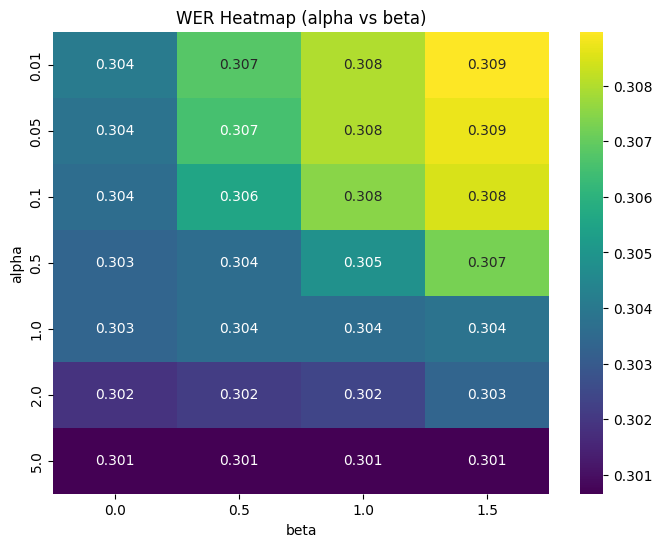

In [22]:
pivot = df.pivot(index="alpha", columns="beta", values="wer")

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")

plt.title("WER Heatmap (alpha vs beta)")
plt.xlabel("beta")
plt.ylabel("alpha")

plt.show()

In [23]:
best = df.loc[df["wer"].idxmin()]
print("BEST CONFIG:")
print(best)

BEST CONFIG:
alpha    5.000000
beta     0.000000
wer      0.300660
cer      0.094036
Name: 24, dtype: float64


In [24]:
beam_lm_rescore_alpha = best["alpha"]
beam_lm_rescore_beta = best["beta"]

### Выводы
Вот тут уже какие-то серьезные расхождения начались с референсами, wer оромный, cer вцелом похож
Я не выбирал семплы, но вообще логика ошибок примерно такая:
- ЛМки исправляют то, на чем они учились, то есть в нашем случае будет исправляться грамматика
- Из-за этого же эффекта, редкие слова они будут переделывать в те, которые им покажется наиболее значимым
- Мне болше нравится как shallow fusion работает, какая-то более внятная интуиция лежит за переоценкой полностью слова, чем за переоценкой гипотез в рантайме

## Task 7
Проверка лучших конфигураций с триграмм моделью

In [25]:
best_confs ={
    'greedy': None,
    'beam': {
        'beam_width': 10
    },
    'beam_lm': {
        'beam_width': 10,
        'alpha': 1,
        'beta': 0
    },
    'beam_lm_rescore': {
        'alpha': beam_lm_rescore_alpha,
        'beta': beam_lm_rescore_beta,
        'beam_width': 3
    }
}

def run_exp(conf, method):
    if conf is not None:
        decoder = Wav2Vec2Decoder(
            lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
            **conf
        )
    else:
        decoder = Wav2Vec2Decoder(lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz")

    def predictor(tensor):
        return decoder.decode(raw_logits=tensor, method=method)

    res = {
        'earnings22_test': {},
        'librispeech_test_other': {}
    }

    for ds_name in res:
        wer, cer = evaluate_ds(ds_name=ds_name, predictor=predictor)
        res[ds_name] = {
            'wer': wer,
            'cer': cer
        }

    return res

In [26]:
res = {}
for name in best_confs:
    res[name] = run_exp(conf=best_confs[name], method=name)

/Users/petr.marfutenko/Desktop/ai-talent-hub-itmo-speech-course/assignments/assignment2/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at facebook/wav2vec2-base-100h were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v', 'wav2vec2.mask_time_emb_vector']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a Bert

In [27]:
rows = []

for method, datasets in res.items():
    row = {
        "Method": method,
        "LibriSpeech WER": datasets.get("librispeech_test_other", {}).get("wer", "-") * 100,
        "LibriSpeech CER": datasets.get("librispeech_test_other", {}).get("cer", "-") * 100,
        "Earnings22 WER": datasets.get("earnings22_test", {}).get("wer", "-") * 100,
        "Earnings22 CER": datasets.get("earnings22_test", {}).get("cer", "-") * 100,
    }
    rows.append(row)

df = pd.DataFrame(rows)

df

,Method,LibriSpeech WER,LibriSpeech CER,Earnings22 WER,Earnings22 CER
0,greedy,11.219751,3.812800,55.030120,25.692042
1,beam,26.717184,8.318395,62.349398,27.595156
2,beam_lm,26.081643,7.921128,63.855422,28.595372
3,beam_lm_rescore,30.065999,9.403614,63.885542,28.152033


### Выводы
Я не очень понял почему, но по in domain data лучший вариант по wer и по cer это greedy. У меня есть подозрение, что я неверно реализовал методы с лмками, но я прверял их работу и они работют. Но факт остается фактом, greedy - топ.  
По out of domain data интереснее - там все настолько плохо, что я бы подумал надо ли такое кому-то показывать. Но в целом логика понятная, модель не сильно понимает чего и куда от нее хотят

## Task 7b
Test temperature sweep on OOD data

In [28]:
temperatures = [0.5, 1.0, 1.5, 2.0]

results = []

decoder = Wav2Vec2Decoder(
    lm_model_path="lm/3-gram.pruned.1e-7.arpa.gz",
    beam_width=10
)

methods = ["greedy", "beam_lm"]

for method in methods:
    print(f"\n=== METHOD: {method} ===")
    
    for T in temperatures:
        print(f"Running temperature={T}...")
        
        decoder.temperature = T

        def predictor(tensor):
            return decoder.decode(raw_logits=tensor, method=method)

        wer, cer = evaluate_ds(
            ds_name="earnings22_test",
            predictor=predictor
        )

        results.append({
            "method": method,
            "temperature": T,
            "wer": wer,
            "cer": cer,
        })

df = pd.DataFrame(results)

print("\nRESULTS:")
print(df)

/Users/petr.marfutenko/Desktop/ai-talent-hub-itmo-speech-course/assignments/assignment2/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at facebook/wav2vec2-base-100h were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v', 'wav2vec2.mask_time_emb_vector']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a Bert


=== METHOD: greedy ===
Running temperature=0.5...


100%|██████████| 200/200 [00:00<00:00, 6896.60it/s]


Running temperature=1.0...


100%|██████████| 200/200 [00:00<00:00, 2386.44it/s]


...

Running temperature=1.5...


100%|██████████| 200/200 [01:01<00:00,  3.26it/s]


Running temperature=2.0...


100%|██████████| 200/200 [01:01<00:00,  3.25it/s]


RESULTS:
    method  temperature       wer       cer
0   greedy          0.5  0.550301  0.256920
1   greedy          1.0  0.550301  0.256920
2   greedy          1.5  0.550301  0.256920
3   greedy          2.0  0.550301  0.256920
4  beam_lm          0.5  0.622892  0.278222
5  beam_lm          1.0  0.622289  0.278060
6  beam_lm          1.5  0.661446  0.290712
7  beam_lm          2.0  0.809639  0.333315


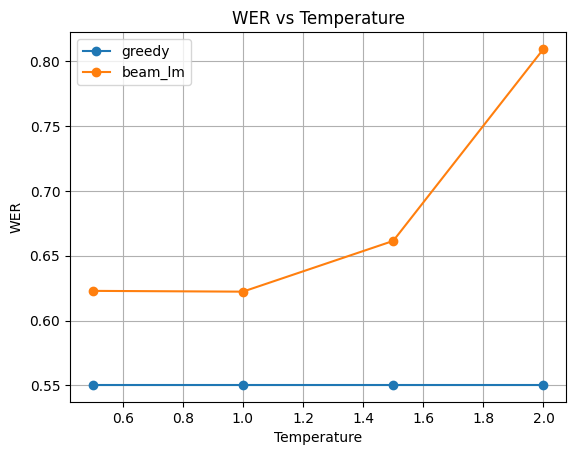

In [29]:
plt.figure()

for method in methods:
    subset = df[df["method"] == method]
    plt.plot(subset["temperature"], subset["wer"], marker='o', label=method)

plt.xlabel("Temperature")
plt.ylabel("WER")
plt.title("WER vs Temperature")
plt.legend()
plt.grid()

plt.show()

### Вывод
В этой части greedy тоже выйиграл, хоть он и менее устойчив к изменению температуры и я думаю тут дело как раз в рескоринге лмкой

## Task 9
Тест лучших конфигов на двух лмках

In [30]:
methods = ["greedy", "beam_lm"]

lms = {
    "librispeech_3gram": "lm/3-gram.pruned.1e-7.arpa.gz",
    "financial": "lm/financial-3gram.arpa",  # <-- поменяй путь если нужно
}

datasets = ['earnings22_test', 'librispeech_test_other']

results = []

for lm_name, lm_path in lms.items():
    print(f"\n=== LM: {lm_name} ===")

    decoder = Wav2Vec2Decoder(
        lm_model_path=lm_path,
        beam_width=10,
        alpha=1,
        beta=0,
        temperature=1.0
    )

    for method in methods:
        print(f"\n--- METHOD: {method} ---")

        for ds in datasets:
            print(f"Running on {ds}...")

            def predictor(tensor):
                return decoder.decode(raw_logits=tensor, method=method)

            wer, cer = evaluate_ds(
                ds_name=ds,
                predictor=predictor
            )

            results.append({
                "lm": lm_name,
                "method": method,
                "dataset": ds,
                "wer": wer,
                "cer": cer,
            })

df = pd.DataFrame(results)

print("\n=== RESULTS ===")
print(df)

/Users/petr.marfutenko/Desktop/ai-talent-hub-itmo-speech-course/assignments/assignment2/.venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



=== LM: librispeech_3gram ===


Some weights of the model checkpoint at facebook/wav2vec2-base-100h were not used when initializing Wav2Vec2ForCTC: ['wav2vec2.encoder.pos_conv_embed.conv.weight_g', 'wav2vec2.encoder.pos_conv_embed.conv.weight_v', 'wav2vec2.mask_time_emb_vector']
- This IS expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Wav2Vec2ForCTC from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-100h and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'wav


--- METHOD: greedy ---
Running on earnings22_test...


100%|██████████| 200/200 [00:00<00:00, 8018.94it/s]


...


--- METHOD: beam_lm ---
Running on earnings22_test...


100%|██████████| 200/200 [00:59<00:00,  3.38it/s]


Running on librispeech_test_other...


100%|██████████| 200/200 [01:13<00:00,  2.73it/s]


=== RESULTS ===
                  lm   method                 dataset       wer       cer
0  librispeech_3gram   greedy         earnings22_test  0.550301  0.256920
1  librispeech_3gram   greedy  librispeech_test_other  0.112198  0.038128
2  librispeech_3gram  beam_lm         earnings22_test  0.638554  0.285954
3  librispeech_3gram  beam_lm  librispeech_test_other  0.260816  0.079211
4          financial   greedy         earnings22_test  0.550301  0.256920
5          financial   greedy  librispeech_test_other  0.112198  0.038128
6          financial  beam_lm         earnings22_test  0.931928  0.375324
7          financial  beam_lm  librispeech_test_other  0.722317  0.184584


In [31]:
table = df.pivot_table(
    index=["method"],
    columns=["dataset", "lm"],
    values=["wer", "cer"]
)

print(table)

                    cer                                           \
dataset earnings22_test                   librispeech_test_other   
lm            financial librispeech_3gram              financial   
method                                                             
beam_lm        0.375324          0.285954               0.184584   
greedy         0.256920          0.256920               0.038128   

                                      wer                    \
dataset                   earnings22_test                     
lm      librispeech_3gram       financial librispeech_3gram   
method                                                        
beam_lm          0.079211        0.931928          0.638554   
greedy           0.038128        0.550301          0.550301   

                                                  
dataset librispeech_test_other                    
lm                   financial librispeech_3gram  
method                                            
beam_lm 

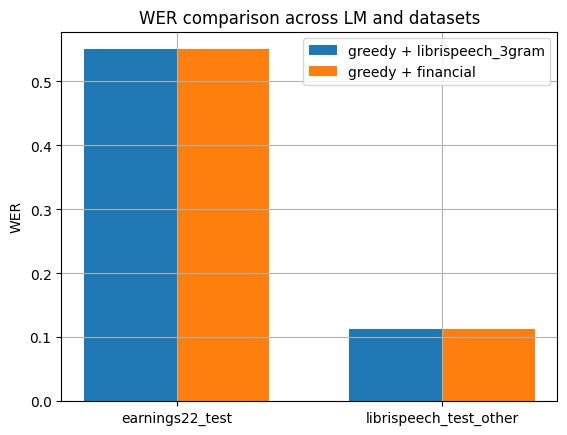

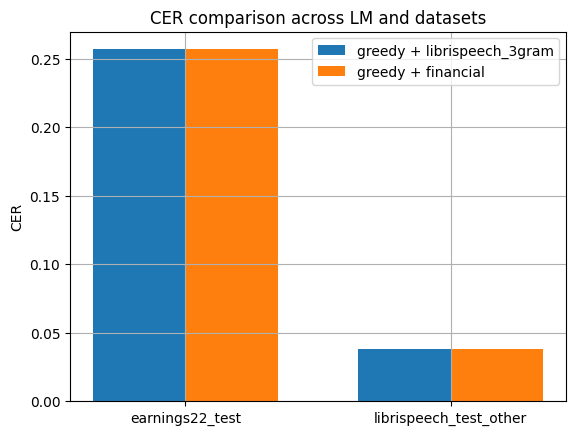

In [32]:
metrics = ["wer", "cer"]

for metric in metrics:
    plt.figure()

    for i, method in enumerate(methods):
        subset = df[df["method"] == method]

        x = np.arange(len(datasets))
        width = 0.35

        for j, lm_name in enumerate(lms.keys()):
            vals = [
                subset[(subset["dataset"] == ds) & (subset["lm"] == lm_name)][metric].values[0]
                for ds in datasets
            ]

            plt.bar(x + j*width, vals, width, label=f"{method} + {lm_name}")

        break  # чтобы не дублировать бары для каждого метода

    plt.xticks(x + width/2, datasets)
    plt.ylabel(metric.upper())
    plt.title(f"{metric.upper()} comparison across LM and datasets")
    plt.legend()
    plt.grid()

    plt.show()

### Выводы
Никакого влияния от лмок нет)  
Я может что-то не так собрал, но финансовая лмка ухудшила качество)
Я загружу ее в репозиторий и можно будет потестить   

## Conclusion
Выводы неоднозначные:
- Лабораторная очень интересная и задача весьма прикольная, затягивало писать такие алгоритмы
- Самый простой метод `greedy` работа ровно так как и ожидается
- Все методы с LM моделями, ровно как и эксперименты с заменой LM моделей, работают ровно наоборот от того как ожидается. Метрики хуже референса, при изменении паматеров декодирования при ожидаемом увеличении метрик они ухудшаются или не дают результата

Лично мне лабораторная понравилась, хоть я и не смог показать тех результатов, которые ожидались